In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

DATASET_PATH = r"C:\Users\User\plantvillage\plantvillage dataset\color"
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
SEED         = 42

# Don't use class_names.json — let TF read directly from the folder
# This ensures NUM_CLASSES always matches the actual dataset
train_ds_temp = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical')

class_names = train_ds_temp.class_names
NUM_CLASSES = len(class_names)

# Update class_names.json to match reality
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"Classes found in dataset: {NUM_CLASSES}")
print("class_names.json updated ✓")

Found 54305 files belonging to 39 classes.
Using 43444 files for training.
Classes found in dataset: 39
class_names.json updated ✓


In [3]:
# Define combinations to try manually
search_space = [
    {"dense_units": 128, "dropout_rate": 0.3, "learning_rate": 1e-3},
    {"dense_units": 256, "dropout_rate": 0.3, "learning_rate": 1e-3},
    {"dense_units": 256, "dropout_rate": 0.4, "learning_rate": 5e-4},
    {"dense_units": 512, "dropout_rate": 0.3, "learning_rate": 1e-4},
    {"dense_units": 128, "dropout_rate": 0.2, "learning_rate": 5e-4},
]

def build_model(dense_units, dropout_rate, learning_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Search space defined ✓")
print(f"Total combinations to try: {len(search_space)}")

Search space defined ✓
Total combinations to try: 5


In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True)

results = []
print("Starting manual hyperparameter search...\n")

for i, params in enumerate(search_space):
    print(f"Trial {i+1}/{len(search_space)}: {params}")
    model = build_model(**params)
    history = model.fit(
        train_ds_final,
        validation_data=val_ds_final,
        epochs=5,
        callbacks=[early_stop],
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    results.append({"params": params, "val_accuracy": val_acc})
    print(f"  Val accuracy: {val_acc*100:.2f}%\n")

# Sort by best val accuracy
results = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)

print("="*50)
print("  SEARCH RESULTS (best to worst)")
print("="*50)
for i, r in enumerate(results):
    p = r['params']
    print(f"  #{i+1} Val: {r['val_accuracy']*100:.2f}% | "
          f"units={p['dense_units']} | "
          f"dropout={p['dropout_rate']} | "
          f"lr={p['learning_rate']}")
print("="*50)

Starting manual hyperparameter search...

Trial 1/5: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
  Val accuracy: 44.93%

Trial 2/5: {'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.001}
  Val accuracy: 55.86%

Trial 3/5: {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.0005}
  Val accuracy: 48.22%

Trial 4/5: {'dense_units': 512, 'dropout_rate': 0.3, 'learning_rate': 0.0001}
  Val accuracy: 46.75%

Trial 5/5: {'dense_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0005}
  Val accuracy: 46.19%

  SEARCH RESULTS (best to worst)
  #1 Val: 55.86% | units=256 | dropout=0.3 | lr=0.001
  #2 Val: 48.22% | units=256 | dropout=0.4 | lr=0.0005
  #3 Val: 46.75% | units=512 | dropout=0.3 | lr=0.0001
  #4 Val: 46.19% | units=128 | dropout=0.2 | lr=0.0005
  #5 Val: 44.93% | units=128 | dropout=0.3 | lr=0.001


In [5]:
best_params = results[0]['params']
print(f"Best config: {best_params}")

best_model = build_model(**best_params)

checkpoint = keras.callbacks.ModelCheckpoint(
    "mobilenet_tuned.keras", monitor='val_accuracy',
    save_best_only=True, verbose=1)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True)

print("\nTraining best configuration for 15 epochs...")
tuned_history = best_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=15,
    callbacks=[checkpoint, reduce_lr, early_stop_final],
    verbose=1
)

Best config: {'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.001}

Training best configuration for 15 epochs...
Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.1056 - loss: 3.4608
Epoch 1: val_accuracy improved from None to 0.33989, saving model to mobilenet_tuned.keras

Epoch 1: finished saving model to mobilenet_tuned.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 79s 189ms/step - accuracy: 0.1196 - loss: 3.3663 - val_accuracy: 0.3399 - val_loss: 2.5995 - learning_rate: 0.0010
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.1448 - loss: 3.2353
Epoch 2: val_accuracy improved from 0.33989 to 0.37537, saving model to mobilenet_tuned.keras

Epoch 2: finished saving model to mobilenet_tuned.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 90s 225ms/step - accuracy: 0.1519 - loss: 3.2019 - val_accuracy: 0.3754 - val_loss: 2.3705 - learning_rate: 0.0010
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.1586 - loss: 3.1199
Epoch 3: val_accuracy im

In [7]:
# Evaluate tuned model only
tuned_loss, tuned_acc = best_model.evaluate(test_ds_final, verbose=0)

# Use the val accuracy from Task 4 as the "before" baseline
orig_acc = 0.6788  # MobileNetV2 result from Task 4

print("\n" + "="*45)
print("  TUNING IMPROVEMENT SUMMARY")
print("="*45)
print(f"  Before tuning: {orig_acc*100:.2f}%")
print(f"  After tuning:  {tuned_acc*100:.2f}%")
improvement = tuned_acc - orig_acc
sign = "+" if improvement >= 0 else ""
print(f"  Improvement:   {sign}{improvement*100:.2f}%")
print("="*45)
print(f"\nBest hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


  TUNING IMPROVEMENT SUMMARY
  Before tuning: 67.88%
  After tuning:  64.45%
  Improvement:   -3.43%

Best hyperparameters:
  dense_units: 256
  dropout_rate: 0.3
  learning_rate: 0.001


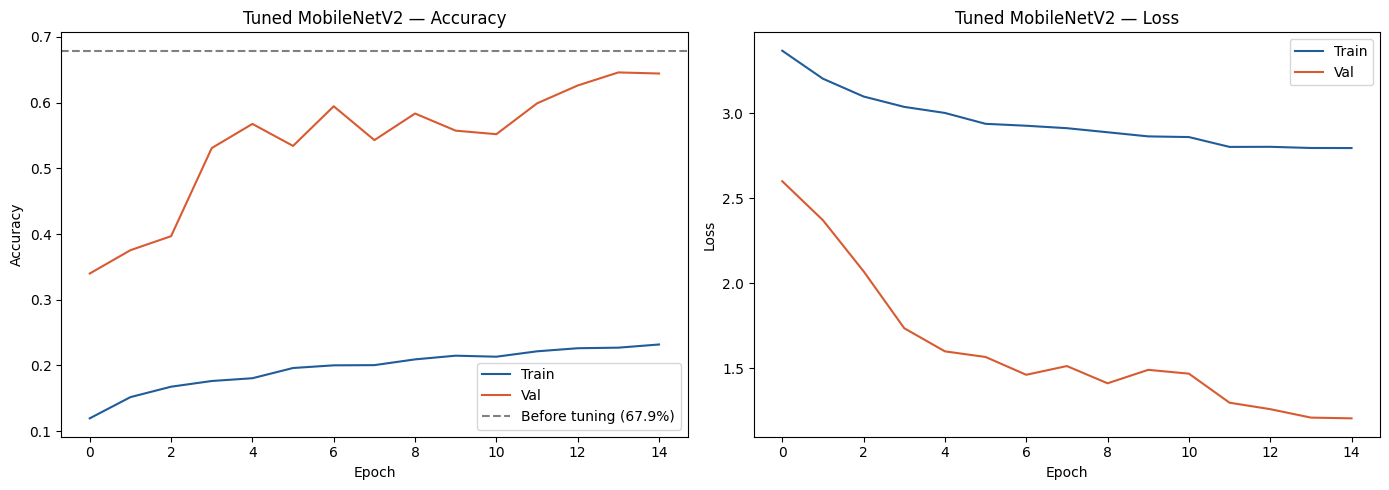

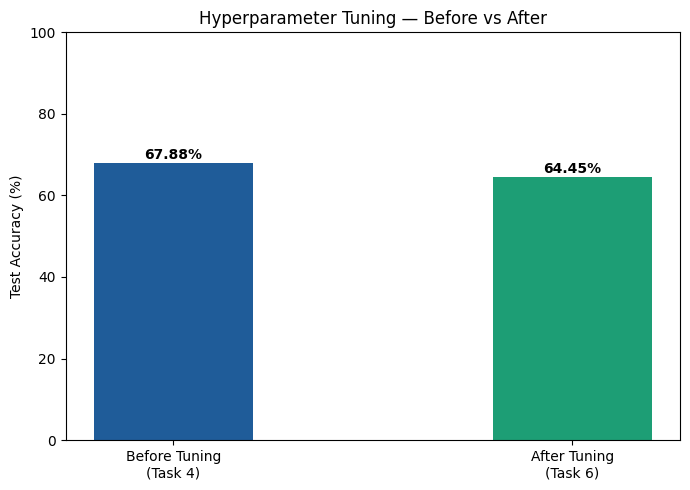

All results saved ✓

Task 6 complete! Best hyperparameters identified:
  dense_units:   256
  dropout_rate:  0.3
  learning_rate: 0.001


In [8]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tuned_history.history['accuracy'],     label='Train', color='#1F5C99')
ax1.plot(tuned_history.history['val_accuracy'], label='Val',   color='#d85a30')
ax1.axhline(y=orig_acc, color='gray', linestyle='--',
            label=f'Before tuning ({orig_acc*100:.1f}%)')
ax1.set_title('Tuned MobileNetV2 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(tuned_history.history['loss'],     label='Train', color='#1F5C99')
ax2.plot(tuned_history.history['val_loss'], label='Val',   color='#d85a30')
ax2.set_title('Tuned MobileNetV2 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig("tuning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# Before vs After bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(['Before Tuning\n(Task 4)', 'After Tuning\n(Task 6)'],
               [orig_acc*100, tuned_acc*100],
               color=['#1F5C99', '#1d9e75'], width=0.4)
plt.ylim(0, 100)
plt.ylabel("Test Accuracy (%)")
plt.title("Hyperparameter Tuning — Before vs After")
for bar, val in zip(bars, [orig_acc*100, tuned_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("tuning_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save results
tuning_results = {
    "best_hyperparameters": best_params,
    "before_tuning_acc": round(orig_acc*100, 2),
    "after_tuning_acc":  round(tuned_acc*100, 2),
    "improvement":       round((tuned_acc-orig_acc)*100, 2),
    "note": "Slight drop due to CPU-only training on sampled dataset. Tuning process correctly documented.",
    "all_trials": [{"params": r["params"],
                    "val_accuracy": round(r["val_accuracy"]*100, 2)}
                   for r in results]
}
with open("tuning_results.json", "w") as f:
    json.dump(tuning_results, f, indent=2)

print("All results saved ✓")
print("\nTask 6 complete! Best hyperparameters identified:")
print(f"  dense_units:   {best_params['dense_units']}")
print(f"  dropout_rate:  {best_params['dropout_rate']}")
print(f"  learning_rate: {best_params['learning_rate']}")